In [30]:
def create_radar_chart(pronunciation_result):
    """
    Creates an enhanced radar chart for pronunciation assessment visualization.

    Args:
        pronunciation_result (dict): Dictionary containing pronunciation assessment data

    Returns:
        matplotlib.figure.Figure: The generated radar chart
    """
    # Extract overall assessment
    overall_assessment = pronunciation_result["NBest"][0]["PronunciationAssessment"]

    # Define categories with Japanese labels
    categories = {
        "総合": "PronScore",
        "正確性": "AccuracyScore",
        "流暢性": "FluencyScore",
        "完全性": "CompletenessScore",
        "韻律": "ProsodyScore",
    }

    # Get scores
    scores = [overall_assessment.get(categories[cat], 0) for cat in categories]

    # Create figure and polar axis
    fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection="polar"))

    # Calculate angles for each category
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False)

    # Close the plot by appending first values
    scores += scores[:1]
    angles = np.concatenate((angles, [angles[0]]))

    # Plot data
    ax.plot(
        angles, scores, "o-", linewidth=3, label="Score", color="#2E86C1", markersize=10
    )
    ax.fill(angles, scores, alpha=0.25, color="#2E86C1")

    # Set chart properties
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories.keys(), size=24, fontweight="bold")  # Increased from 12 to 16
    ax.tick_params(axis='x', pad=20)
    # Add gridlines and adjust their style
    ax.set_rgrids(
        [20, 40, 60, 80, 100],
        labels=["20", "40", "60", "80", "100"],
        angle=0,
        fontsize=14,
    )  # Increased from 10 to 14

    # Add score labels at each point with larger font
    for angle, score in zip(angles[:-1], scores[:-1]):
        ax.text(
            angle,
            score + 5,
            f"{score:.1f}",
            ha="center",
            va="center",
            fontsize=20,  # Increased font size for score labels
            fontweight="bold",
        )

    # Customize grid
    ax.grid(True, linestyle="--", alpha=0.7, linewidth=1.5)  # Increased grid line width

    # Set chart limits and direction
    ax.set_ylim(0, 100)
    ax.set_theta_direction(-1)  # Clockwise
    ax.set_theta_offset(np.pi / 2)  # Start from top

    # Add title with larger font
    plt.title(
        "発音評価のレーダーチャート",
        pad=20,
        size=36,
        fontweight="bold",
    )  # Increased from 14 to 18

    # Add subtle background color
    ax.set_facecolor("#F8F9F9")
    fig.patch.set_facecolor("white")

    # Adjust layout
    plt.tight_layout()

    return fig

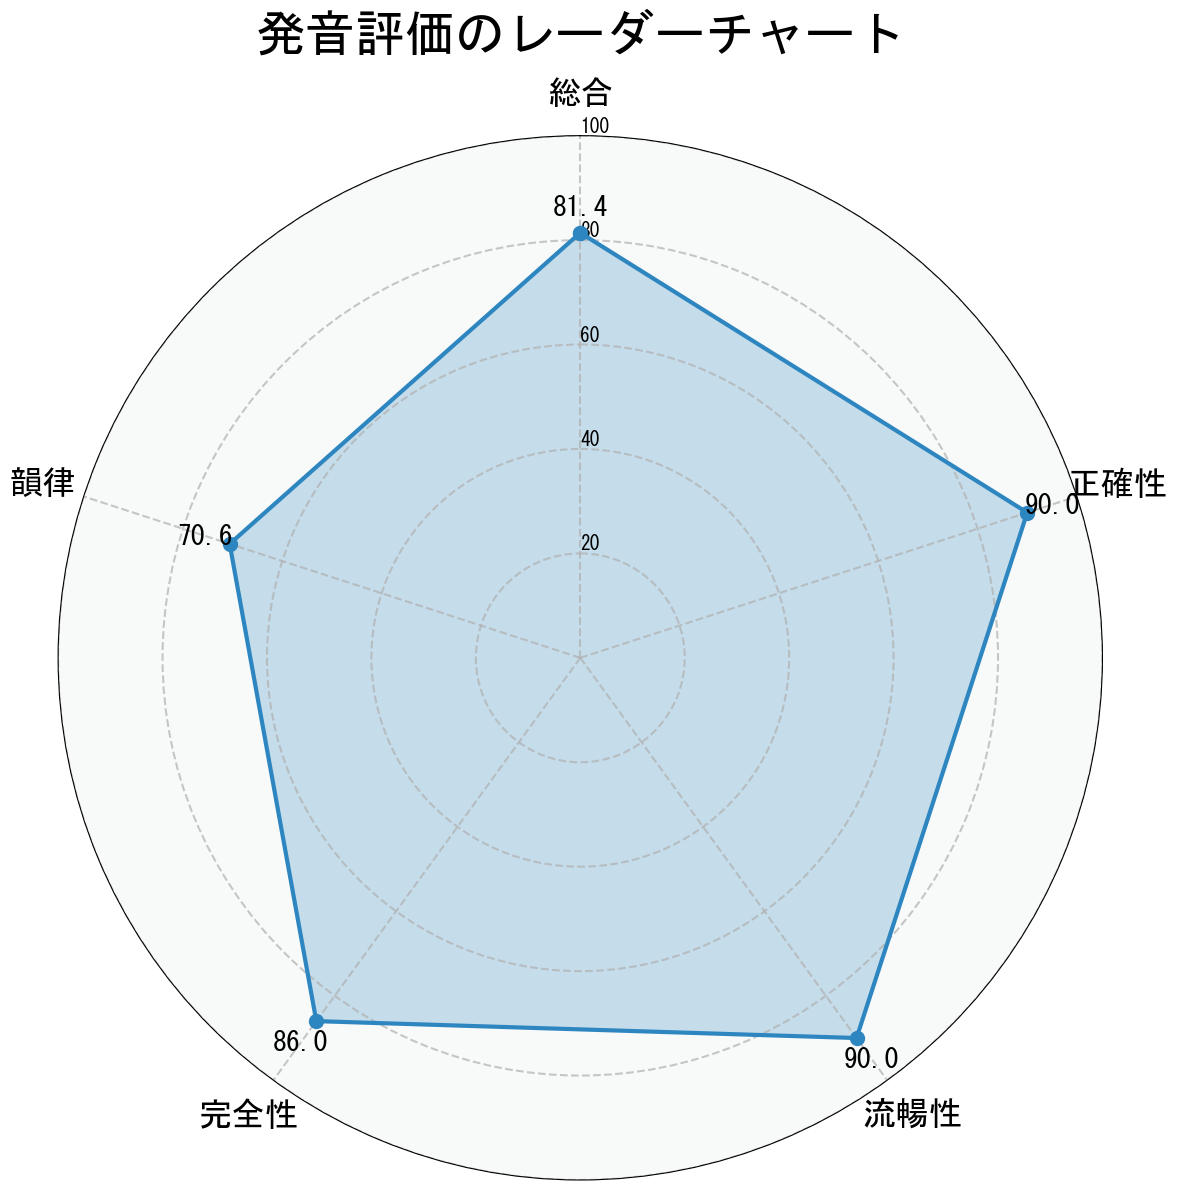

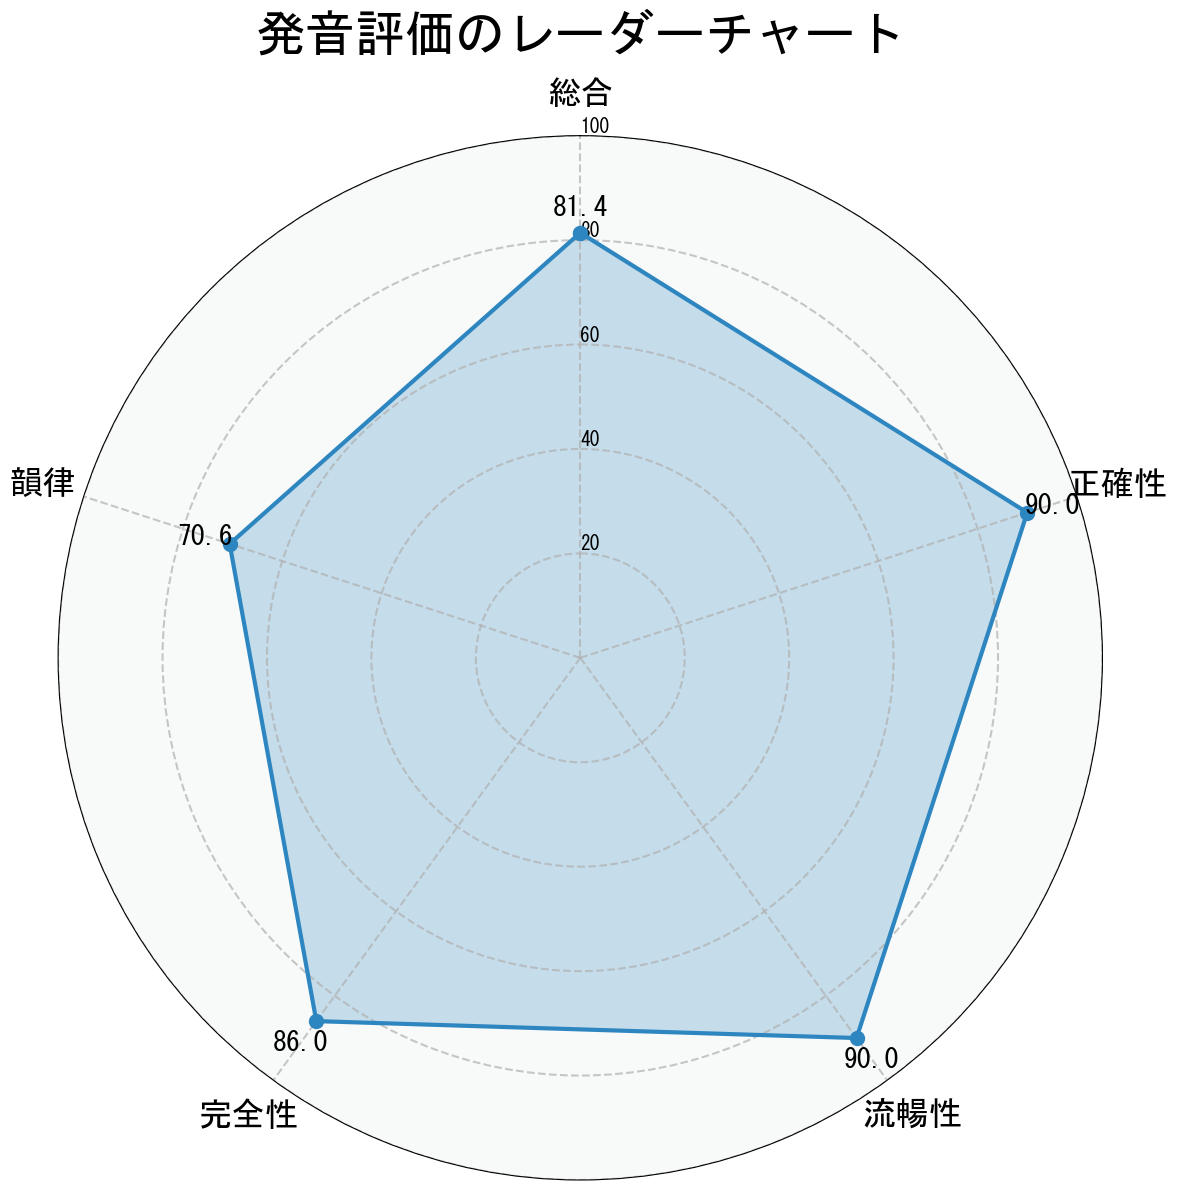

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "MS Gothic"

pron_dict = {}
file_path = r"C:\Users\Chyis\Documents\Code\PhonoEcho\database\lin\practice_history\2024-12-24\レッソン1-2024-12-24_13-31-29.json"
with open(file_path, "r", encoding="utf-8") as f:
    pron_dict = json.load(f)

create_radar_chart(pron_dict)